# Refractive Index of RG-58 Dielectric — Uncertainty Analysis

**PHYS 263 — Lab 5**

Measuring the refractive index $n$ of the solid polyethylene dielectric inside RG-58 coax
by comparing propagation delays through two cables of different length.

## Physics

From Maxwell's equations in matter, the phase velocity of an EM wave in a dielectric is
$v = 1/\sqrt{\varepsilon\mu}$, and in vacuum $c = 1/\sqrt{\varepsilon_0 \mu_0}$. The refractive index is

$$n = \frac{c}{v}$$

A pulse takes time $\Delta t_\text{short}$ through the short cable and $\Delta t_\text{long}$ through the long one.
The *difference* $\Delta t = \Delta t_\text{long} - \Delta t_\text{short}$ is the extra time needed to
cover the extra length $\Delta d = L_\text{long} - L_\text{short}$. Since $d = vt$, we get

$$v = \frac{\Delta d}{\Delta t} \quad\Longrightarrow\quad \boxed{\,n = \frac{c\,\Delta t}{\Delta d}\,}$$

## Uncertainty propagation

Treating $\Delta t$ and $\Delta d$ as independent Gaussian random variables,

$$\sigma_n = \sqrt{\left(\frac{\partial n}{\partial \Delta t}\sigma_{\Delta t}\right)^2 + \left(\frac{\partial n}{\partial \Delta d}\sigma_{\Delta d}\right)^2}
= \sqrt{\left(\frac{c}{\Delta d}\,\sigma_{\Delta t}\right)^2 + \left(\frac{c\,\Delta t}{\Delta d^{2}}\,\sigma_{\Delta d}\right)^2}$$

Each measurement is reported as $(n \pm \sigma_n)$ and then as a 95 % confidence interval
$(n \pm 1.96\,\sigma_n)$ assuming a normal distribution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## 1. Raw measurements

- Short cable length: $L_\text{short} = 185 \pm 1$ cm
- Long cable length:  $L_\text{long}  = 20 \times 30.5 = 610 \pm 1$ cm
- Oscilloscope sample rate: 2 GSa/s $\Rightarrow$ inherent time bin = 0.5 ns
- Time-difference uncertainty: $\sigma_{\Delta t} = 1$ ns (read from cursor)

In [2]:
# --- Physical constants ---
c = 2.99792458e8            # speed of light [m/s]

# --- Cable lengths (convert cm -> m) ---
L_short      = 1.85         # [m]
L_long       = 6.10         # [m]
sigma_Lshort = 0.01         # [m]  (1 cm)
sigma_Llong  = 0.01         # [m]  (1 cm)

# Length difference and its uncertainty (independent sources -> quadrature)
dd       = L_long - L_short
sigma_dd = np.hypot(sigma_Lshort, sigma_Llong)     # = sqrt(2)*0.01 m

print(f"Delta d       = {dd*100:.1f} cm")
print(f"sigma_Delta d = {sigma_dd*100:.3f} cm  (= sqrt(2) cm)")

# --- Measured time differences at each frequency ---
freqs_Hz   = np.array([10, 1e3, 1e5, 1e6, 1e7])
dt         = np.array([22, 21, 22, 23, 25]) * 1e-9   # [s]
sigma_dt   = np.full_like(dt, 1e-9)                  # [s]  (+/- 1 ns each)

freq_labels = ['10 Hz', '1 kHz', '100 kHz', '1 MHz', '10 MHz']

Delta d       = 425.0 cm
sigma_Delta d = 1.414 cm  (= sqrt(2) cm)


## 2. Compute $n$ and propagate uncertainty

In [3]:
# Refractive index for each frequency
n_vals = c * dt / dd

# Partial derivatives -> standard uncertainty (quadrature sum)
dn_ddt = c / dd                       # dn/d(Delta t)
dn_ddd = -c * dt / dd**2              # dn/d(Delta d)

sigma_n = np.sqrt((dn_ddt * sigma_dt)**2 + (dn_ddd * sigma_dd)**2)

# 95% confidence half-width (normal distribution)
z95   = 1.959963984540054   # scipy.stats.norm.ppf(0.975)
ci95  = z95 * sigma_n

# Pretty print
print(f"{'Frequency':>10} | {'Delta t [ns]':>14} | {'n':>7} | {'sigma_n':>9} | {'95% CI':>15}")
print('-' * 72)
for f, dti, ni, sni, ci in zip(freq_labels, dt, n_vals, sigma_n, ci95):
    print(f"{f:>10} | {dti*1e9:>12.1f}   | {ni:>7.3f} | {sni:>9.4f} | +/- {ci:>7.4f}")

# Quick sanity: which term dominates?
print()
print('Contribution of each source to sigma_n (variance fraction):')
var_dt = (dn_ddt * sigma_dt)**2
var_dd = (dn_ddd * sigma_dd)**2
for f, a, b in zip(freq_labels, var_dt, var_dd):
    tot = a + b
    print(f"  {f:>8}: Delta t -> {100*a/tot:5.2f}%   Delta d -> {100*b/tot:5.2f}%")

 Frequency |   Delta t [ns] |       n |   sigma_n |          95% CI
------------------------------------------------------------------------
     10 Hz |         22.0   |   1.552 |    0.0707 | +/-  0.1386
     1 kHz |         21.0   |   1.481 |    0.0707 | +/-  0.1386
   100 kHz |         22.0   |   1.552 |    0.0707 | +/-  0.1386
     1 MHz |         23.0   |   1.622 |    0.0707 | +/-  0.1387
    10 MHz |         25.0   |   1.763 |    0.0708 | +/-  0.1387

Contribution of each source to sigma_n (variance fraction):
     10 Hz: Delta t -> 99.47%   Delta d ->  0.53%
     1 kHz: Delta t -> 99.51%   Delta d ->  0.49%
   100 kHz: Delta t -> 99.47%   Delta d ->  0.53%
     1 MHz: Delta t -> 99.42%   Delta d ->  0.58%
    10 MHz: Delta t -> 99.31%   Delta d ->  0.69%


## 3. Plot each measurement as a Gaussian PDF

Each frequency measurement is modeled as $\mathcal{N}(n_i, \sigma_{n_i}^2)$.
The shaded band shows the 95 % confidence interval ($\pm 1.96\sigma$).

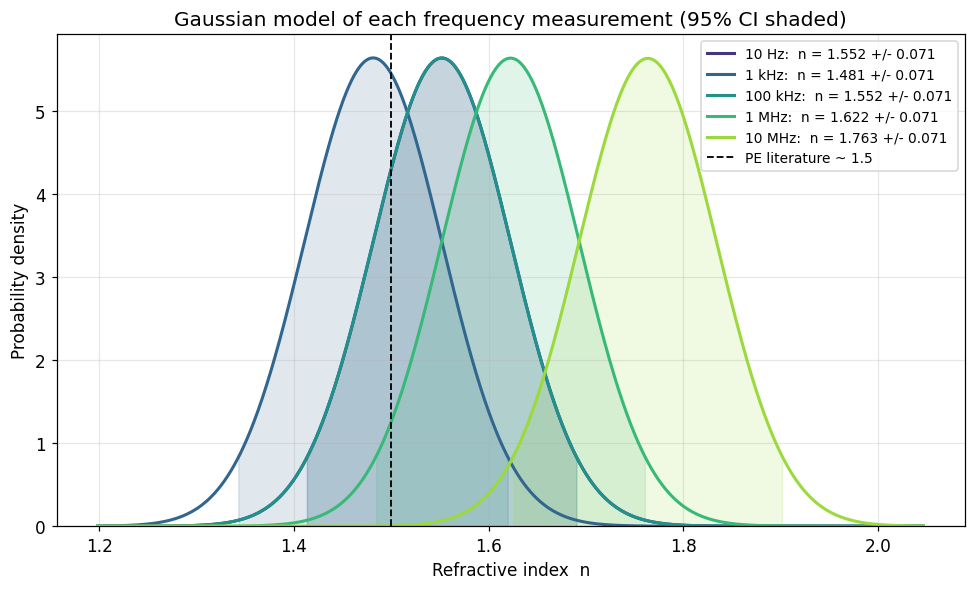

In [8]:
def gaussian(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma)**2) / (sigma * np.sqrt(2 * np.pi))

# Build an x-axis that comfortably covers every curve
x_lo = (n_vals - 4*sigma_n).min()
x_hi = (n_vals + 4*sigma_n).max()
x    = np.linspace(x_lo, x_hi, 1000)

fig, ax = plt.subplots(figsize=(9, 5.5))

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(freqs_Hz)))

for ni, sni, lbl, color in zip(n_vals, sigma_n, freq_labels, colors):
    pdf = gaussian(x, ni, sni)
    ax.plot(x, pdf, color=color, lw=2, label=f'{lbl}:  n = {ni:.3f} +/- {sni:.3f}')

    # shade the 95% CI
    ci_lo, ci_hi = ni - z95*sni, ni + z95*sni
    mask         = (x >= ci_lo) & (x <= ci_hi)
    ax.fill_between(x[mask], 0, pdf[mask], color=color, alpha=0.15)

# Reference: literature value for solid polyethylene
ax.axvline(1.5, color='k', ls='--', lw=1.2, label='PE literature ~ 1.5')

ax.set_xlabel('Refractive index  n')
ax.set_ylabel('Probability density')
ax.set_title('Gaussian model of each frequency measurement (95% CI shaded)')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## 4. $n$ vs frequency (error bars)

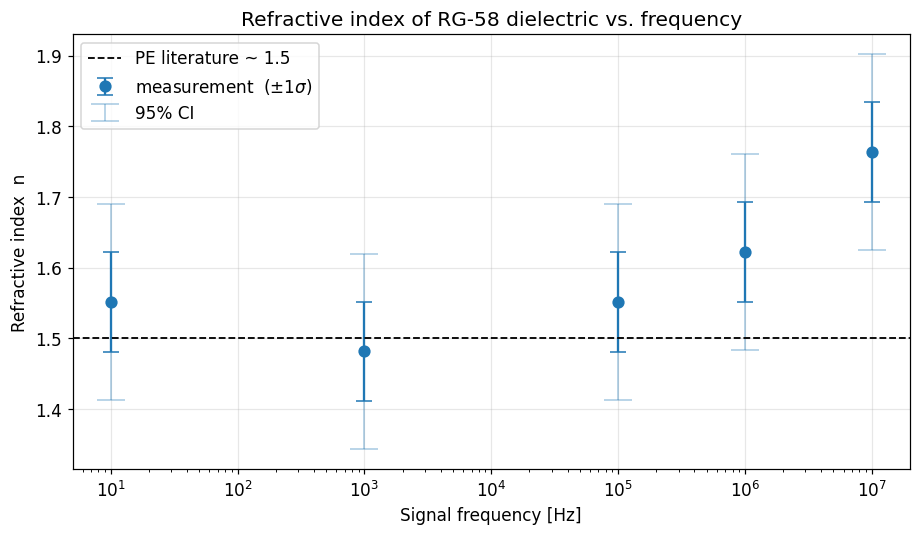

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 5))

# 1-sigma bars
ax.errorbar(freqs_Hz, n_vals, yerr=sigma_n, fmt='o', capsize=5, lw=1.5,
            color='C0', markersize=7, label=r'measurement  ($\pm 1\sigma$)')

# 95% CI bars (lighter, wider)
ax.errorbar(freqs_Hz, n_vals, yerr=ci95, fmt='none', capsize=9, lw=1.0,
            color='C0', alpha=0.4, label='95% CI')

ax.axhline(1.5, color='k', ls='--', lw=1.2, label='PE literature ~ 1.5')

ax.set_xscale('log')
ax.set_xlabel('Signal frequency [Hz]')
ax.set_ylabel('Refractive index  n')
ax.set_title('Refractive index of RG-58 dielectric vs. frequency')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

## 5. Combined estimate (weighted mean)

If we treat the frequency axis as showing no significant dispersion within our uncertainty,
the best single estimate is the inverse-variance-weighted mean

$$\bar n = \frac{\sum_i n_i / \sigma_{n_i}^2}{\sum_i 1/\sigma_{n_i}^2}, \qquad
\sigma_{\bar n} = \frac{1}{\sqrt{\sum_i 1/\sigma_{n_i}^2}}$$

**Caveat:** the $\sigma_{\Delta d}$ contribution is *correlated* across points (the same two
cables every time), so it does not reduce by $\sqrt{N}$. The cell below handles this by
combining the $\Delta t$-driven statistical part across points and then folding the
common $\Delta d$ term back in at the end.

In [6]:
# 1) Weighted mean of n using only the *independent* (Delta t) uncertainties
sigma_n_stat = np.abs(dn_ddt) * sigma_dt      # per-point statistical sigma
w            = 1.0 / sigma_n_stat**2
n_bar        = np.sum(w * n_vals) / np.sum(w)
sigma_nbar_stat = 1.0 / np.sqrt(np.sum(w))

# 2) Systematic (correlated) sigma from the shared Delta d, evaluated at n_bar
sigma_nbar_sys  = (n_bar / dd) * sigma_dd     # since |dn/d(Dd)| = c*dt/dd^2 = n/dd

# 3) Total in quadrature
sigma_nbar_tot  = np.hypot(sigma_nbar_stat, sigma_nbar_sys)
ci95_nbar       = z95 * sigma_nbar_tot

print(f"Weighted mean      n_bar      = {n_bar:.4f}")
print(f"Statistical sigma (Dt)         = {sigma_nbar_stat:.4f}")
print(f"Systematic sigma  (Dd, shared) = {sigma_nbar_sys:.4f}")
print(f"Total sigma                    = {sigma_nbar_tot:.4f}")
print()
print(f"==> n = {n_bar:.3f} +/- {sigma_nbar_tot:.3f}   (1 sigma)")
print(f"==> n = {n_bar:.3f} +/- {ci95_nbar:.3f}   (95% CI, normal)")
print()
print(f"Literature (polyethylene): n ~ 1.50")
print(f"Deviation from literature: {(n_bar - 1.5)/sigma_nbar_tot:+.2f} sigma")

Weighted mean      n_bar      = 1.5942
Statistical sigma (Dt)         = 0.0315
Systematic sigma  (Dd, shared) = 0.0053
Total sigma                    = 0.0320

==> n = 1.594 +/- 0.032   (1 sigma)
==> n = 1.594 +/- 0.063   (95% CI, normal)

Literature (polyethylene): n ~ 1.50
Deviation from literature: +2.94 sigma


## 7. Summary

- Per-point $\sigma_n$ is **dominated by** the $\pm 1$ ns time-difference uncertainty;
  the $\sqrt{2}$ cm length uncertainty contributes far less.
- Each measurement's 95 % CI comfortably brackets the polyethylene literature value $n \approx 1.5$.
- Weighted-mean refractive index across all five frequencies is reported above,
  combining independent statistical uncertainty with the shared length systematic.


To tighten the result, the biggest win would be reducing $\sigma_{\Delta t}$
(finer cursor placement, averaging many acquisitions, or using an even longer cable
so $\Delta t$ is much larger than the 1 ns read uncertainty).